<a href="https://colab.research.google.com/github/miffylim2308/ADALL_github/blob/main/Test_Grab_Transbport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color='red'>**dated 30.07.2026 2pm**

#**Chapter 1. Setup and load Libraries**

In [1]:
# Core Libraries
import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib
import sklearn as sklearn

# Modelling libraries and preprocessing
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# libraries version
np_ver=np.__version__
pd_ver=pd.__version__
sklearn_ver=sklearn.__version__
matplotlib_ver = matplotlib.__version__

RANDOM_STATE = 42

print('Setup complete')

Setup complete


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Chapter 2. Upload and Read Dataset**

In [2]:
import pandas as pd
# Example: Replace this with the raw URL of your GitHub fileynth
github_raw_url = 'https://raw.githubusercontent.com/miffylim2308/ADALL_github/refs/heads/main/synthetic_grab_transport_v3_10000_23pct_cancel.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Successfully loaded data from GitHub!")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")


Successfully loaded data from GitHub!


,booking_id,booking_datetime,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,...,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled,cancel_reason
0,BK2026007041,6/3/2026 0:10,0,Friday,3,0,0,1,0,Queenstown,...,Medium,1.10,0,0,0,11.66,Current,Good,0,Not Cancelled
1,BK2026017909,11/6/2026 9:31,9,Thursday,6,0,1,0,0,CBD,...,Severe,1.15,0,1,10,6.64,One version behind,Good,0,Not Cancelled
2,BK2026010896,9/4/2026 9:42,9,Thursday,4,0,1,0,0,Sentosa,...,Low,1.49,0,0,0,40.07,Current,Poor,1,Changed plans/weather
3,BK2026003508,1/2/2026 23:47,23,Sunday,2,1,0,1,0,CBD,...,Low,1.00,0,1,3,21.48,Current,Good,0,Not Cancelled
4,BK2026013146,29/4/2026 12:57,12,Wednesday,4,0,0,0,0,Jurong East,...,Medium,1.00,0,0,0,7.12,Current,Good,0,Not Cancelled


#**Chapter 3. Set up OpenAI**

In [3]:
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

OpenAI client is ready.


#**Chapter 4. Quick Dataset Inspection**

In [4]:
print('Shape:', df.shape)

display(df.head())

print('\nInfo:')
display(df.info())

print('\nColumns:', df.columns.tolist())

print("\nDescribe:")
display(df.describe(include='all').transpose())

missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

duplicate_count = df.duplicated().sum()
print("\nDuplicate count:", duplicate_count)

Shape: (10000, 49)


,booking_id,booking_datetime,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,...,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled,cancel_reason
0,BK2026007041,6/3/2026 0:10,0,Friday,3,0,0,1,0,Queenstown,...,Medium,1.10,0,0,0,11.66,Current,Good,0,Not Cancelled
1,BK2026017909,11/6/2026 9:31,9,Thursday,6,0,1,0,0,CBD,...,Severe,1.15,0,1,10,6.64,One version behind,Good,0,Not Cancelled
2,BK2026010896,9/4/2026 9:42,9,Thursday,4,0,1,0,0,Sentosa,...,Low,1.49,0,0,0,40.07,Current,Poor,1,Changed plans/weather
3,BK2026003508,1/2/2026 23:47,23,Sunday,2,1,0,1,0,CBD,...,Low,1.00,0,1,3,21.48,Current,Good,0,Not Cancelled
4,BK2026013146,29/4/2026 12:57,12,Wednesday,4,0,0,0,0,Jurong East,...,Medium,1.00,0,0,0,7.12,Current,Good,0,Not Cancelled



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 49 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   booking_id                       10000 non-null  object 
 1   booking_datetime                 10000 non-null  object 
 2   booking_hour                     10000 non-null  int64  
 3   day_of_week                      10000 non-null  object 
 4   month                            10000 non-null  int64  
 5   is_weekend                       10000 non-null  int64  
 6   is_peak_hour                     10000 non-null  int64  
 7   is_late_night                    10000 non-null  int64  
 8   public_holiday                   10000 non-null  int64  
 9   pickup_zone                      10000 non-null  object 
 10  pickup_zone_type                 10000 non-null  object 
 11  dropoff_zone                     10000 non-null  object 
 12  dropoff_zone

None


Columns: ['booking_id', 'booking_datetime', 'booking_hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'public_holiday', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone', 'dropoff_zone_type', 'airport_trip', 'cbd_trip', 'distance_km', 'estimated_trip_duration_min', 'vehicle_type', 'payment_method', 'customer_segment', 'loyalty_tier', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'weather', 'is_raining', 'traffic_level', 'surge_multiplier', 'surge_changed_after_booking', 'promo_applied', 'promo_discount_sgd', 'estimated_fare_sgd', 'app_version', 'network_quality', 'customer_cancelled', 'cancel_reason']

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,10000,10000,BK2026003811,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_datetime,10000,9796,28/6/2026 14:54,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_hour,10000.0,NaN,NaN,NaN,11.7025,6.839303,0.0,6.0,12.0,18.0,23.0
day_of_week,10000,7,Thursday,1475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,10000.0,NaN,NaN,NaN,3.4967,1.70114,1.0,2.0,4.0,5.0,6.0
is_weekend,10000.0,NaN,NaN,NaN,0.2831,0.450527,0.0,0.0,0.0,1.0,1.0
is_peak_hour,10000.0,NaN,NaN,NaN,0.3021,0.459191,0.0,0.0,0.0,1.0,1.0
is_late_night,10000.0,NaN,NaN,NaN,0.2744,0.446234,0.0,0.0,0.0,1.0,1.0
public_holiday,10000.0,NaN,NaN,NaN,0.0324,0.177069,0.0,0.0,0.0,0.0,1.0
pickup_zone,10000,15,CBD,918,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values:
 booking_id                            0
booking_datetime                      0
booking_hour                          0
day_of_week                           0
month                                 0
is_weekend                            0
is_peak_hour                          0
is_late_night                         0
public_holiday                        0
pickup_zone                           0
pickup_zone_type                      0
dropoff_zone                          0
dropoff_zone_type                     0
airport_trip                          0
cbd_trip                              0
distance_km                           0
estimated_trip_duration_min           0
vehicle_type                          0
payment_method                        0
customer_segment                      0
loyalty_tier                       3268
customer_tenure_days                  0
rides_last_7_days                     0
rides_last_30_days                    0
customer_cancel_rate_90

#**Prompt LLM for Problem Framing**

In [ ]:
# PROMPT - LLM-assisted problem framing

prompt_framing = f"""
You are an experienced data scientist specialising in machine learning for business problems.
Your task is to translate the following business problem into a machine learning modelling objective.
=======================
DATASET PREVIEW
=======================
{df.head()}

=========================
BUSINESS CONTEXT
=========================
Business Problem:
Grab Ride Operations Manager has observed a high rate of customer cancellations before the trip commencement over the past few months.

Business Objective:
Develop a machine learning model to predict the probability that a customer will cancel a ride before trip commencement.

Business Goal:
Reduce the customer pre-trip cancellation rate by enabling proactive operational interventions.

Dataset Context:
The dataset contains Grab ride-hailing booking data.
Each row represents one booking made by a customer. Around 23% of the dataset are records that customers cancelled before the trip commencement.
The dataset includes customer information, booking details, driver availability, pricing, weather, traffic conditions, and booking outcomes.

=========================
TASK
=========================
Answer the following questions:
1. What should the machine learning modelling objective be?
2. Which column should be used as the target variable? Explain why.
3. Which evaluation model(s) and metric(s) would you recommend for this prediction problem? Explain why these metrics would be meaningful and easy for business stakeholders to understand.
4. Who are the main business stakeholders that would use the model?
5. Identify three potential risks or pitfalls when developing or deploying this model.

=========================
IMPORTANT
=========================
Use ONLY the information provided in the business context and dataset profile.
Do NOT invent columns, business processes or stakeholders that are not supported by the information provided.
If an answer requires assumptions, clearly label them as "Assumption".
If information is not available, state the assumptions you are making.
Present your answers using clear headings and concise explanations suitable for a university report.
"""
print('=== Prompt to send ===')
print(prompt_framing[:2000])

response_framing = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_framing
)
print('\n=== LLM response ===')
print(response_framing.output_text)



=== Prompt to send ===

You are an experienced data scientist specialising in machine learning for business problems.
Your task is to translate the following business problem into a machine learning modelling objective.
DATASET PREVIEW
     booking_id booking_datetime  booking_hour day_of_week  month  is_weekend  \
0  BK2026007041    6/3/2026 0:10             0      Friday      3           0   
1  BK2026017909   11/6/2026 9:31             9    Thursday      6           0   
2  BK2026010896    9/4/2026 9:42             9    Thursday      4           0   
3  BK2026003508   1/2/2026 23:47            23      Sunday      2           1   
4  BK2026013146  29/4/2026 12:57            12   Wednesday      4           0   

   is_peak_hour  is_late_night  public_holiday  pickup_zone  ...  \
0             0              1               0   Queenstown  ...   
1             1              0               0          CBD  ...   
2             1              0               0      Sentosa  ...   
3    

#**Chapter 5. Build Payload Text**

In [40]:
#===== Chapter 5. Build Payload Text =====#

payload_text = ''

# 0. Business context and objective
payload_text += '=== BUSINESS OBJECTIVE ===\n'
payload_text += 'Dataset context: The dataset contains ride-hailing booking data. Each row represents one booking made by a customer.\n'
payload_text += 'The dataset includes customer information, booking details, driver availability, weather, traffic conditions, and booking outcomes.\n'
payload_text += 'Business Goal: Develop a machine learning model to predict the probability that a customer will cancel a ride before trip commencement.\n'
payload_text += 'Utimately to reduce the customer pre-trip cancellation rate by enabling proactive operational interventions.\n'
payload_text += 'Intended Users: Grab Ride Operations Manager whose one of his goal is to reduce the customer pre-trip cancellation rate.\n'
payload_text += 'Questions:\n'
payload_text += '- Which features influence customer cancellation?\n'
payload_text += '- What data quality issues exist?\n'
payload_text += '- What preprocessing is required?\n\n'

# 1. Shape
payload_text += '=== SHAPE ===\n'
payload_text += 'Rows: ' + str(df.shape[0]) + '\n'
payload_text += 'Columns: ' + str(df.shape[1]) + '\n\n'

# 2. Sample records
payload_text += '=== SAMPLE RECORDS ===\n'
payload_text += df.head(5).to_string(index=False)
payload_text += '\n\n'

# 3. Column names and data types
payload_text += '=== COLUMNS AND DATA TYPES ===\n'
payload_text += df.dtypes.to_string()
payload_text += '\n\n'

# 4. Numeric summary
payload_text += '=== NUMERIC SUMMARY ===\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()
payload_text += '\n\n'

# 5. Null summary
payload_text += "=== NULL SUMMARY ===\n"
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
payload_text += null_summary.to_string()
payload_text += '\n\n'

# 6. Missing values
payload_text += '=== MISSING VALUES ===\n'
missing_table = pd.DataFrame()
missing_table['missing_count'] = df.isna().sum()
missing_table['missing_pct'] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += missing_table.to_string()
payload_text += '\n\n'

# 7. Unique values per column
payload_text += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
payload_text += unique_table.to_string()
payload_text += '\n\n'

# 8 Correlation between numeric columns
payload_text += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table = df.corr(numeric_only=True).round(2)
payload_text += correlation_table.to_string()
payload_text += '\n\n'

# 9. Top 10 values for categorical columns
payload_text += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    payload_text += 'No categorical columns found.\n'
else:
    for col in categorical_columns:
        payload_text += '\nColumn: ' + col + '\n'
        payload_text += df[col].value_counts(dropna=False).head(10).to_string()
        payload_text += '\n'

payload_text += '\n'

# 10. Skewness of numeric columns
payload_text += '=== SKEWNESS OF NUMERIC COLUMNS ===\n'
skew_table = df.select_dtypes(include='number').skew().round(2)
payload_text += skew_table.to_string()
payload_text += '\n\n'

# 11. Outlier summary
payload_text += '=== OUTLIER SUMMARY (IQR METHOD) ===\n'

numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_pct = round(outlier_count / len(df) * 100, 2)

    payload_text += f'{column}: {outlier_count} ({outlier_pct}%)\n'

payload_text += '\n'

# 12. Leakage scan: columns with all unique values
payload_text += "=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n"
leak_cols = df.columns[df.nunique() == len(df)]
payload_text +=str(list(leak_cols))
payload_text +="\n\n"

# 13. Simple warning checks
payload_text += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)
payload_text += 'Possible ID-like columns: ' + str(id_like_columns) + '\n'
payload_text += 'Constant columns: ' + str(constant_columns) + '\n'
duplicate_count = df.duplicated().sum()
duplicate_pct = round(duplicate_count / len(df) * 100, 2)
payload_text += (
    f'Duplicate rows: {duplicate_count} ({duplicate_pct}%)\n'
)

print(payload_text)



=== BUSINESS OBJECTIVE ===
Dataset context: The dataset contains ride-hailing booking data. Each row represents one booking made by a customer.
The dataset includes customer information, booking details, driver availability, weather, traffic conditions, and booking outcomes.
Business Goal: Develop a machine learning model to predict the probability that a customer will cancel a ride before trip commencement.
Utimately to reduce the customer pre-trip cancellation rate by enabling proactive operational interventions.
Intended Users: Grab Ride Operations Manager whose one of his goal is to reduce the customer pre-trip cancellation rate.
Questions:
- Which features influence customer cancellation?
- What data quality issues exist?
- What preprocessing is required?

=== SHAPE ===
Rows: 10000
Columns: 46

=== SAMPLE RECORDS ===
 booking_hour day_of_week  month  is_weekend  is_peak_hour  is_late_night  public_holiday pickup_zone pickup_zone_type dropoff_zone dropoff_zone_type  airport_trip  c

#**Chapter 6. Prompt LLM to review Data Quality using Payload Text**

In [ ]:
#===== Chapter 6. Quality Assessment =====#

prompt_quality = f"""
You are an expert data scientist with extensive knowledge of tree-based models.
Always justify recommendations using reasoning trace based ONLY on the dataset profile.
============================
DATASET PROFILE
============================
{payload_text}

============================
TASK
============================
Assess the dataset's quality and modelling readiness.

1. Identify all confirmed data quality or modelling-readiness issues.

For each issue, provide:
- Issue
- Column(s) affected
- Evidence from the dataset profile
- Why it may affect analysis or modelling
- Recommended action
- Priority (High / Medium / Low)

2. Identify any potential issues that require further investigation but cannot be confirmed from the dataset profile alone.
3. Identify any features which are higly correlated with other features.
4. Highlight the strengths of the dataset (for example, no missing values, no duplicates, appropriate data types, etc.).

5. State whether the dataset is ready for machine learning modelling using ONE of the following ratings:
- Ready
- Ready with Minor Cleaning
- Ready with Moderate Cleaning
- Not Ready
Provide a brief justification.

6. Recommend the Top 5 next steps before modelling.

7. Provide simple and executable python script to handle the identified issues.
- Original dataset: df
- Define one helper function for each issue.
- Then define a wrapper function that calls these helper with true false option as user choice
- Provide a single line of code to run the overall wrapper function. Save the final dataset to cleaned_df.
- Do not split data, encode categorical columns or model first.

========================
IMPORTANT INSTRUCTIONS
========================

- Use only the information contained in the dataset profile.
- Do NOT assume information that is not provided.
- If evidence is unavailable, state "Not available" instead of guessing.
- Reference the relevant dataset profile section whenever possible (e.g., Missing Values, Numeric Summary, Correlation Matrix, Warning Checks).
- Do NOT recommend dropping a column solely because it appears in a warning.
- Treat ID-like, high-cardinality, constant, near-constant and outlier warnings as items requiring investigation, not automatic removal.
- Do NOT treat correlation as proof of causation.
- Do NOT recommend removing outliers unless there is evidence they are invalid or unsuitable for the business objective.
- If skewness, outlier summary, feature importance, or other analyses are not included in the dataset profile, state that they were not available instead of inferring results.
- Distinguish clearly between confirmed issues and potential issues.
- Keep recommendations practical, concise, and suitable for a data analytics student.

========================
OUTPUT FORMAT
========================

Overall Modelling Readiness
---------------------------
Readiness Rating:
Brief Justification:

Confirmed Issues
----------------
For each issue, use the following format:

Issue:
Column(s):
Evidence:
Impact:
Recommended Action:
Priority:

Potential Issues Requiring Investigation
-----------------------------------------
For each potential issue, use:

Issue:
Reason Further Investigation is Needed:

Dataset Strengths
-----------------
- ...
- ...
- ...

Checks with No Issues
---------------------
- ...
- ...
- ...

Top 5 Recommended Next Steps
----------------------------
1.
2.
3.

Overall Summary
---------------
Provide a concise summary (3–5 sentences) describing the dataset's overall quality and readiness for machine learning modelling.
"""

response_quality= client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_quality
)
print('\n=== LLM response ===')
print(response_quality.output_text)





=== LLM response ===
Overall Modelling Readiness
---------------------------
Readiness Rating: **Ready with Minor Cleaning**

Brief Justification:  
The dataset has **no missing values except `loyalty_tier` (32.68%)**, **no duplicates**, and contains a complete target column `customer_cancelled` with no nulls. However, there are confirmed modelling-readiness concerns: a **text/ID leakage risk** (`booking_id` is unique per row), and **missingness that must be handled** for `loyalty_tier`. Additionally, a **leakage/target-proxy risk** may exist from `cancel_reason` (it is present for all rows, but the profile does not show whether it is populated only for cancellations), so it requires careful handling/verification.  

Confirmed Issues
----------------
1) **Potential target leakage / row-identifier leakage**
- **Issue:** `booking_id` is unique per row and can act as an ID that memorizes outcomes.
- **Column(s):** `booking_id`
- **Evidence:** Dataset profile → **Possible Leakage Columns*

#**Chapter 7. Data Cleaning (selective) based on LLM's Data Quality Review**

In [24]:
# ===== Chapter 7. Data Cleaning =====
# Drop booking_id and cancel_reason, handle missingness in loyalty_tier, parse booking_datetime

import pandas as pd

# ---------- fill missing loyalty_tier ---------- #
def fix_missing_loyalty_tier(df, use_true_false=True):
    """
    If True: fill missing loyalty_tier with 'Unknown' category.
    """
    if not use_true_false:
        return df
    if 'loyalty_tier' in df.columns:
        df = df.copy()
        df['loyalty_tier'] = df['loyalty_tier'].astype('object')
        df['loyalty_tier'] = df['loyalty_tier'].fillna('Unknown')
    return df

# ---------- drop ID-like booking_id ---------- #
def drop_booking_id(df, use_true_false=True):
    """
    If True: drop ID-like booking_id to avoid memorization.
    """
    if not use_true_false:
        return df
    if 'booking_id' in df.columns:
        df = df.drop(columns=['booking_id'])
    return df

# ---------- drop cancel_reason ---------- #
def drop_cancel_reason_if_label_proximate(df, use_true_false=True):
    """
    If True: drop cancel_reason to prevent using post-outcome proxy information.
    """
    if not use_true_false:
        return df
    if 'cancel_reason' in df.columns:
        df = df.drop(columns=['cancel_reason'])
    return df

# ---------- parse booking_datetime ---------- #
def parse_booking_datetime_safely(df, use_true_false=True):
    """
    If True: attempt to parse booking_datetime robustly; keep original columns used elsewhere.
    """
    if not use_true_false:
        return df
    if 'booking_datetime' in df.columns:
        df = df.copy()
        # Try day-first parsing; if some formats are month-first, this may still work in practice.
        df['booking_datetime_parsed'] = pd.to_datetime(df['booking_datetime'], errors='coerce', dayfirst=True)
        # Do not drop original booking_datetime to avoid breaking downstream references.
    return df

# ---------- Wrapper ----------
def clean_dataset_wrapper(df,
                          fix_loyalty=True,
                          drop_id=True,
                          drop_cancel_reason=True,
                          parse_datetime=True):
    df_clean = df
    df_clean = fix_missing_loyalty_tier(df_clean, use_true_false=fix_loyalty)
    df_clean = drop_booking_id(df_clean, use_true_false=drop_id)
    df_clean = drop_cancel_reason_if_label_proximate(df_clean, use_true_false=drop_cancel_reason)
    df_clean = parse_booking_datetime_safely(df_clean, use_true_false=parse_datetime)
    return df_clean

# ---------- One line to run ----------
cleaned_df = clean_dataset_wrapper(df, fix_loyalty=True, drop_id=True, drop_cancel_reason=True, parse_datetime=True)

# --------- Save final dataset to Google Drive for reference -------- #
#cleaned_df.to_csv(
#    "/content/drive/MyDrive/cleaned_df.csv",
#    index=False
#)
print('Data Cleaning is done.')


Data Cleaning is done.


#**Chapter 8. Compare before and after clean dataset**

In [25]:
print('Original rows:', df.shape[0])
print('Cleaned rows:', cleaned_df.shape[0])

print('\nMissing values after cleaning:')
missing_after_cleaning = cleaned_df.isna().sum()
display(missing_after_cleaning.sort_values(ascending=False).head(10))

print('\nColumns after cleaning:')
print(cleaned_df.columns.tolist())

# Columns in each dataframe
df_cols = set(df.columns)
cleaned_cols = set(cleaned_df.columns)

# Compare
removed_cols = sorted(df_cols - cleaned_cols)
added_cols = sorted(cleaned_cols - df_cols)
common_cols = sorted(df_cols & cleaned_cols)

print(f"Original df columns      : {len(df_cols)}")
print(f"Cleaned_df columns       : {len(cleaned_cols)}")
print(f"Common columns           : {len(common_cols)}")
print(f"Removed columns          : {len(removed_cols)}")
print(f"Added columns            : {len(added_cols)}")

print("\n=== Columns Removed from cleaned_df ===")
print(removed_cols)

print("\n=== Columns Added to cleaned_df ===")
print(added_cols)

Original rows: 10000
Cleaned rows: 10000

Missing values after cleaning:


,0
booking_datetime,0
booking_hour,0
day_of_week,0
month,0
is_weekend,0
is_peak_hour,0
is_late_night,0
public_holiday,0
pickup_zone,0
pickup_zone_type,0



Columns after cleaning:
['booking_datetime', 'booking_hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'public_holiday', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone', 'dropoff_zone_type', 'airport_trip', 'cbd_trip', 'distance_km', 'estimated_trip_duration_min', 'vehicle_type', 'payment_method', 'customer_segment', 'loyalty_tier', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'weather', 'is_raining', 'traffic_level', 'surge_multiplier', 'surge_changed_after_booking', 'promo_applied', 'promo_discount_sgd', 'estimated_fare_sgd', 'app_version', 'network_quality', 'customer_cancelled', 'booking_dateti

#**Chapter 7b. Further Data Cleaning**

In [26]:
# Drop specified columns from cleaned_df. Final dataset saved to cleaned2_df

cols_to_drop = ['booking_datetime_parsed', 'booking_datetime']
#'customer_rating','month','payment_method','day_of_week','is_raining']
cleaned2_df = cleaned_df.drop(columns=[c for c in cols_to_drop if c in cleaned_df.columns], errors='ignore')


#**Chapter 7C. Compare before and after further clean dataset**

In [27]:
# Compare before and after cleaning

# Columns in each dataframe
cleaned_cols = set(cleaned_df.columns)
cleaned2_cols = set(cleaned2_df.columns)

# Compare
removed_cols = sorted(cleaned_cols - cleaned2_cols)
added_cols = sorted(cleaned2_cols - cleaned_cols)
common_cols = sorted(cleaned_cols & cleaned2_cols)

print(f"Original df columns      : {len(cleaned_cols)}")
print(f"Cleaned_df columns       : {len(cleaned2_cols)}")
print(f"Common columns           : {len(common_cols)}")
print(f"Removed columns          : {len(removed_cols)}")
print(f"Added columns            : {len(added_cols)}")

print("\n=== Columns Removed from cleaned_df ===")
print(removed_cols)

print("\n=== Columns Added to cleaned_df ===")
print(added_cols)

Original df columns      : 48
Cleaned_df columns       : 46
Common columns           : 46
Removed columns          : 2
Added columns            : 0

=== Columns Removed from cleaned_df ===
['booking_datetime', 'booking_datetime_parsed']

=== Columns Added to cleaned_df ===
[]


In [21]:
cleaned_preview

,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,pickup_zone_type,dropoff_zone,...,is_raining,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled
0,0,Friday,3,0,0,1,0,Queenstown,Residential,Orchard,...,1,Medium,1.10,0,0,0,11.66,Current,Good,0
1,9,Thursday,6,0,1,0,0,CBD,Business,Ang Mo Kio,...,0,Severe,1.15,0,1,10,6.64,One version behind,Good,0
2,9,Thursday,4,0,1,0,0,Sentosa,Leisure,Jurong East,...,1,Low,1.49,0,0,0,40.07,Current,Poor,1
3,23,Sunday,2,1,0,1,0,CBD,Business,Bukit Timah,...,0,Low,1.00,0,1,3,21.48,Current,Good,0
4,12,Wednesday,4,0,0,0,0,Jurong East,Mixed,Orchard,...,0,Medium,1.00,0,0,0,7.12,Current,Good,0


#<font color = 'green'>**Chapter XX-1:TESTING !!! Prompt LLM to recommend baseline model, evaluation metrics**

In [28]:
cleaned_preview = cleaned2_df.head()
prompt_testing = f"""
You are an expert data scientist with extensive experience in binary classification and customer cancellation prediction.

The pandas DataFrame is named `df`.

Target column:
customer_cancelled
- 0 = customer did not cancel
- 1 = customer cancelled

=========================
DATASET PREVIEW
=========================
Dataset {cleaned_preview} is cleaned wihtou missingness, leakages, ID like columns, datetime columns

Use ONLY the information provided in the Dataset Profile.
Do NOT assume columns, relationships, distributions, or values that are not explicitly stated.
If information is unavailable, clearly state that it cannot be determined from the Dataset Profile.

=========================
BUSINESS CONTEXT
=========================

Business Problem:
Grab Ride Operations Manager has observed a high rate of customer cancellations before trip commencement over the past few months.

Business Objective:
Develop a machine learning model that predicts the probability that a customer will cancel a ride before trip commencement.

Business Goal:
Reduce customer pre-trip cancellations by enabling proactive operational interventions.

Dataset Context:
Each row represents one Grab booking.
Approximately 23% of bookings were cancelled before trip commencement.
The dataset contains customer information, booking details, driver availability, pricing, weather, traffic conditions and booking outcomes.

=========================
TASK
=========================

1. Recommend the most appropriate simple baseline model.

For your recommendation:
- Explain why it is suitable.
- Explain why it is a good baseline.
- Relate your reasoning to the dataset characteristics and business objective.

2. Recommend the key hyperparameters for the baseline model.

For each hyperparameter provide:
- Recommended value
- Why it is appropriate
- Whether it helps improve generalisation or reduce overfitting

3. Recommend suitable evaluation metrics for this binary classification problem.

For each metric explain:
- What it measures
- Why it is appropriate
- Whether higher or lower values are better

4. Recommend exploratory data analysis (EDA) plots to better understand the dataset before modelling.

For each plot explain:
- What it shows
- Why it is useful

5. Recommend model evaluation plots after training.

For each plot explain:
- What it shows
- How it helps evaluate the classifier
- Why it is useful for the Grab business problem.
"""

##print('=== Prompt to send ===')
##print(prompt_testing)

response_testing = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_testing
)
print('\n=== LLM response ===')
print(response_testing.output_text)



=== LLM response ===
Below is a baseline-oriented recommendation that uses only the information available in the dataset preview/profile you provided (i.e., binary target, no missingness, no leakage/ID-like columns, no datetime columns, and that ~23% of bookings were cancelled pre-trip).

---

## 1) Most appropriate simple baseline model

### ✅ Recommendation: **Logistic Regression (with regularization)**
Use **L2-regularized logistic regression** (optionally with class weights if needed).

#### Why it is suitable
- The target `customer_cancelled` is **binary** (0/1), so logistic regression directly models  
  \[
  P(customer\_cancelled=1 \mid X)
  \]
- It is a **simple, strong baseline** for tabular classification with mixed feature types (your dataset includes many categorical-like indicators such as `day_of_week`, zone/type fields, weather flags, etc.).

#### Why it is a good baseline for *this* business objective
- Your business goal is to **estimate probability of cancellation be

#<font color = 'green'>**Chapter XX-2:TESTING !!! Pormpt LLM to create scripts based on Chapter XX-1**

In [ ]:
prompt_testing2 = f"""
You are an expert data scientist with extensive experience in binary classification and customer cancellation prediction.

The pandas DataFrame is named `df`.

Target column:
customer_cancelled
- 0 = customer did not cancel
- 1 = customer cancelled

Based on {response_testing}
Generate simple, executable Python code with clear comments.


Important requirements:
- Ensure all result tables are displayed clearly in Google Colab.
- The code must be compatible with commonly used versions of scikit-learn.
- The plotting code must compatible with Matplotlib {matplotlib.__version__} or later.
"""
##print('=== Prompt to send ===')
##print(prompt_testing2)

response_testing2 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_testing2
)
print('\n=== LLM response ===')
print(response_testing2.output_text)




=== LLM response ===
```python
# Baseline binary classification for customer cancellation
# - Target: customer_cancelled (0/1)
# - Model baseline: Logistic Regression
# - Evals: ROC-AUC, PR-AUC, plus threshold metrics
#
# Compatible with scikit-learn (typical versions) + Matplotlib >= 3.10
# Intended for Google Colab (tables displayed clearly)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report
)

# ---------- 0) Basic checks ----------
# df is assumed to already exist in the no

Dataset shape: (10000, 46)
Target rate (cancelled=1): 0.23


,class,count,rate
0,0,7700,0.77
1,1,2300,0.23


,day_of_week,cancel_rate
1,Monday,0.241758
3,Sunday,0.240057
2,Saturday,0.234013
0,Friday,0.233503
5,Tuesday,0.231631
4,Thursday,0.216271
6,Wednesday,0.213287


,month,cancel_rate
0,1,0.239218
4,5,0.234637
2,3,0.228507
5,6,0.228226
1,2,0.224531
3,4,0.223443


,pickup_zone,cancel_rate
3,Changi,0.353014
10,Sentosa,0.277344
4,Clementi,0.249123
5,Jurong East,0.246575
13,Woodlands,0.243860
1,Bukit Timah,0.240367
9,Queenstown,0.234910
8,Punggol,0.227273
14,Yishun,0.217557
11,Serangoon,0.214168


...

,network_quality,cancel_rate
0,Average,0.248681
2,Poor,0.234513
1,Good,0.222106


Numeric columns: 32
Categorical columns: 13
ROC-AUC: 0.9862
PR-AUC : 0.9633


,threshold,precision,recall,f1,false_positive_rate,predicted_positive_rate
14,0.75,0.895089,0.871739,0.883260,0.030519,0.2240
13,0.70,0.880952,0.884783,0.882863,0.035714,0.2310
16,0.85,0.942928,0.826087,0.880649,0.014935,0.2015
17,0.90,0.966146,0.806522,0.879147,0.008442,0.1920
15,0.80,0.915294,0.845652,0.879096,0.023377,0.2125
12,0.65,0.863158,0.891304,0.877005,0.042208,0.2375
11,0.60,0.842105,0.904348,0.872117,0.050649,0.2470
9,0.50,0.818702,0.932609,0.871951,0.061688,0.2620
10,0.55,0.824903,0.921739,0.870637,0.058442,0.2570
8,0.45,0.805970,0.939130,0.867470,0.067532,0.2680



Classification report @ threshold=0.5
              precision    recall  f1-score   support

           0     0.9790    0.9383    0.9582      1540
           1     0.8187    0.9326    0.8720       460

    accuracy                         0.9370      2000
   macro avg     0.8988    0.9355    0.9151      2000
weighted avg     0.9421    0.9370    0.9384      2000



,Pred 0,Pred 1
Actual 0,1445,95
Actual 1,31,429


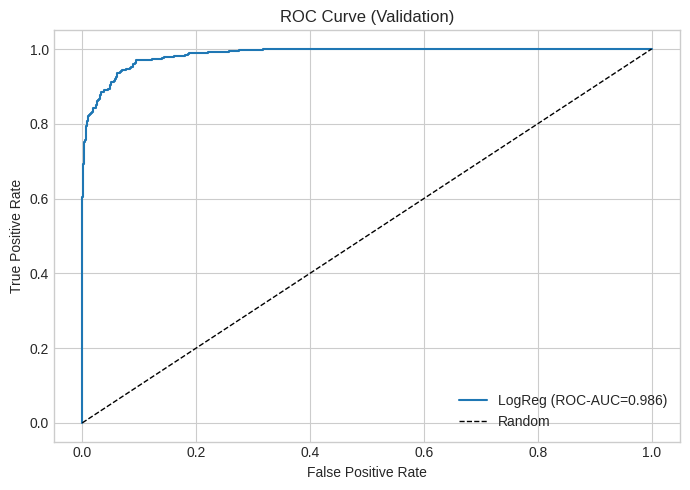

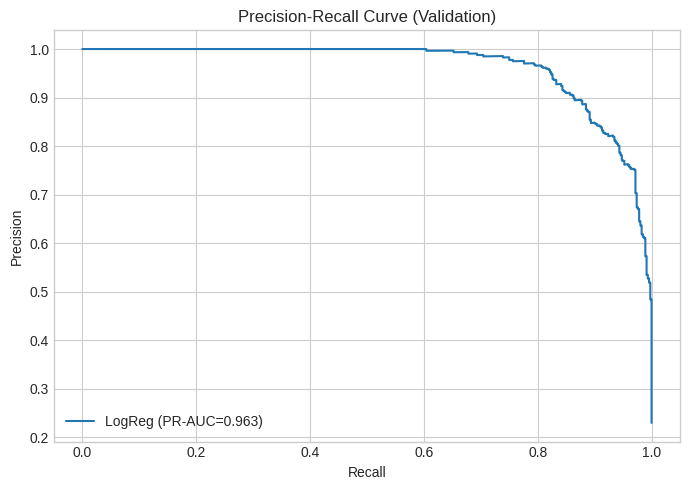

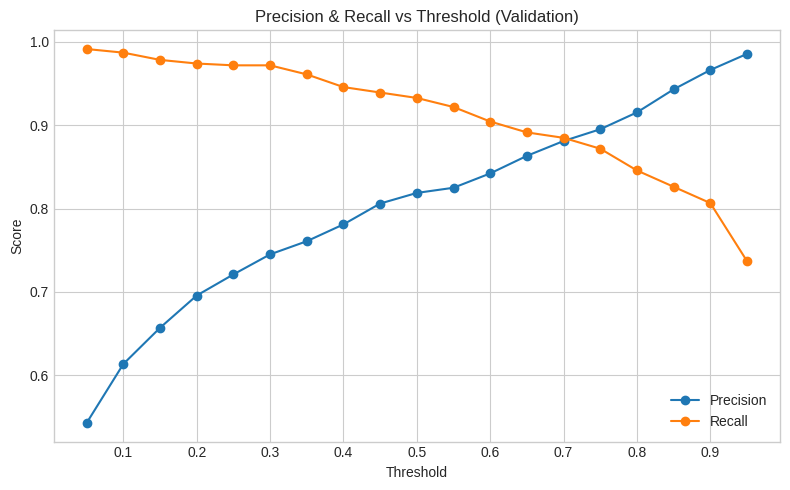

,mean_pred,empirical_rate,count
0,0.011899,0.004762,1260
1,0.145786,0.062500,96
2,0.250220,0.022727,44
3,0.350066,0.279070,43
4,0.438933,0.181818,33
5,0.554338,0.433333,30
6,0.646806,0.281250,32
7,0.758486,0.486486,37
8,0.850519,0.439024,41
9,0.984863,0.966146,384


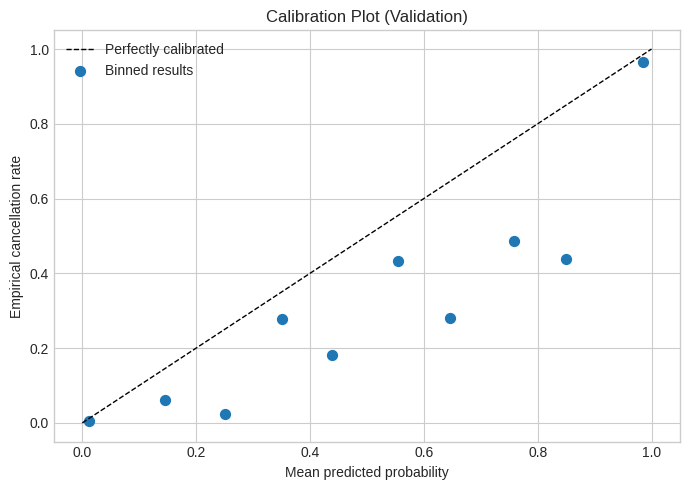


Done.


In [29]:
# Baseline binary classification for customer cancellation
# - Target: customer_cancelled (0/1)
# - Model baseline: Logistic Regression
# - Evals: ROC-AUC, PR-AUC, plus threshold metrics
#
# Compatible with scikit-learn (typical versions) + Matplotlib >= 3.10
# Intended for Google Colab (tables displayed clearly)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report
)

# ---------- 0) Basic checks ----------
# df is assumed to already exist in the notebook.

df=cleaned2_df
target_col = "customer_cancelled"
assert target_col in df.columns, f"Missing target column: {target_col}"

# Drop obvious non-feature identifiers if present (safe: does not harm if absent)
# If you do have a unique ID column, it should not be used for training.
id_like_cols = []
for c in df.columns:
    lc = c.lower()
    if lc in {"id", "customer_id", "trip_id", "request_id", "order_id"}:
        id_like_cols.append(c)

X = df.drop(columns=[target_col] + id_like_cols, errors="ignore")
y = df[target_col].astype(int)

print("Dataset shape:", df.shape)
print("Target rate (cancelled=1):", y.mean().round(4))

# Show a clear table in Colab
display(pd.DataFrame({
    "class": [0, 1],
    "count": [int((y == 0).sum()), int((y == 1).sum())],
    "rate": [float((y == 0).mean()), float((y == 1).mean())]
}))

# ---------- 1) Simple EDA: cancellation rate vs a few time-like / categorical candidates ----------
# This is purely exploratory; it won’t change modeling.
candidate_cats = []
for c in ["day_of_week", "month", "pickup_zone", "pickup_zone_type", "app_version", "network_quality",
          "is_weekend", "is_peak_hour", "is_late_night", "public_holiday", "is_raining", "weather"]:
    if c in df.columns:
        candidate_cats.append(c)

# Plot cancellation rate by selected categorical columns (if they exist)
for c in candidate_cats[:6]:
    tab = df.groupby(c)[target_col].mean().reset_index().rename(columns={target_col: "cancel_rate"})
    # Keep it readable: sort by cancel_rate descending
    tab = tab.sort_values("cancel_rate", ascending=False)
    display(tab.head(15))

# ---------- 2) Train/validation split ----------
# Stratify keeps cancellation rate consistent across splits.
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------- 3) Preprocessing ----------
# Identify numeric vs categorical columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=True, with_std=True))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

# ---------- 4) Baseline model: Logistic Regression ----------
# Recommended baseline settings (from the prompt):
# - penalty: L2
# - C: 1.0 (start)
# - class_weight: balanced
# - solver: lbfgs (works with L2)
clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    solver="lbfgs",
    max_iter=500,
    random_state=42
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", clf)
])

# ---------- 5) Fit ----------
model.fit(X_train, y_train)

# ---------- 6) Predict probabilities on validation ----------
val_proba = model.predict_proba(X_val)[:, 1]  # P(cancel=1)

# ---------- 7) Metrics ----------
roc_auc = roc_auc_score(y_val, val_proba)
pr_auc = average_precision_score(y_val, val_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {pr_auc:.4f}")

# Threshold sweep for an operational view
thresholds = np.linspace(0.05, 0.95, 19)  # adjust density if needed
rows = []
for t in thresholds:
    val_pred = (val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, val_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    rows.append({
        "threshold": round(float(t), 2),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "predicted_positive_rate": val_pred.mean()
    })

metrics_table = pd.DataFrame(rows)
# Sort by F1 to quickly find a reasonable threshold
display(metrics_table.sort_values("f1", ascending=False).head(10))

# Pick threshold=0.5 for a baseline confusion matrix (you can replace with best F1 threshold)
base_threshold = 0.5
val_pred_base = (val_proba >= base_threshold).astype(int)

print("\nClassification report @ threshold=0.5")
print(classification_report(y_val, val_pred_base, digits=4))

cm = confusion_matrix(y_val, val_pred_base)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)
display(cm_df)

# ---------- 8) Plots ----------
plt.style.use("seaborn-v0_8-whitegrid")

# 8.1 ROC curve
fpr, tpr, _ = roc_curve(y_val, val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"LogReg (ROC-AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

# 8.2 Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_val, val_proba)
plt.figure(figsize=(7, 5))
plt.plot(rec, prec, label=f"LogReg (PR-AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

# 8.3 Threshold sweep plot (Precision & Recall vs threshold)
plt.figure(figsize=(8, 5))
plt.plot(metrics_table["threshold"], metrics_table["precision"], marker="o", label="Precision")
plt.plot(metrics_table["threshold"], metrics_table["recall"], marker="o", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold (Validation)")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.tight_layout()
plt.show()

# 8.4 Reliability / calibration plot (simple binning)
# Note: sklearn has CalibrationDisplay; here we implement binning to avoid version differences.
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
bin_ids = np.digitize(val_proba, bins) - 1  # 0..n_bins-1
bin_ids = np.clip(bin_ids, 0, n_bins - 1)

calib = []
for b in range(n_bins):
    mask = bin_ids == b
    if mask.sum() == 0:
        continue
    mean_pred = val_proba[mask].mean()
    mean_true = y_val.iloc[mask].mean()
    calib.append((mean_pred, mean_true, mask.sum()))

calib_df = pd.DataFrame(calib, columns=["mean_pred", "empirical_rate", "count"])
display(calib_df)

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfectly calibrated")
plt.scatter(calib_df["mean_pred"], calib_df["empirical_rate"], s=50, label="Binned results")
plt.xlabel("Mean predicted probability")
plt.ylabel("Empirical cancellation rate")
plt.title("Calibration Plot (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

print("\nDone.")

#<font color = 'green'>**Chapter XX-3:TESTING !!! Ask LLM to give interpretation based on the metrics results**

In [30]:
prompt_testing3=f"""
based on these metrics results

{roc_auc},{pr_auc},{cm_df},{metrics_table},{calib_df}

Give concise model interpretation and recommendations for improvement.
"""
response_testing3 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_testing3
)
print('\n=== LLM response ===')
print(response_testing3.output_text)



=== LLM response ===
### Interpretation (what the metrics say)
- **Two-class performance is very strong for separating classes**:  
  - Confusion matrix shows most cases are correctly classified (e.g., Actual 0: **1445 correct**, Actual 1: **429 correct**).
- **Threshold trade-off is clear** (precision rises, recall slowly drops after ~0.7–0.9, and false positive rate drops sharply):  
  - Around **0.30–0.70**, F1 is highest/near-highest (**~0.83–0.88**), with recall still relatively high (≈0.88–0.97).
  - By **0.90**, recall drops more (**~0.81**) while precision is high (**~0.966**): you miss more positives to reduce false alarms.
  - At **0.95**, F1 collapses (**~0.84**) because recall becomes too low (**~0.737**).
- **Calibration / decision consistency looks questionable at some thresholds**:
  - The table showing **predicted positive rate vs empirical_rate** is very imbalanced and inconsistent (e.g., one bin with predicted 0.984 has empirical 0.966, but several others show big ga

#**Chapter 9. Prompt LLM to create scripts for Baseline Modelling from Train/Test Split till Model Evaluation**

In [ ]:
df = cleaned2_df

prompt_model = f"""
You are an expert data scientist with experience in binary classification models.

The pandas DataFrame is named `df`.
The target column is `customer_cancelled`, where:
- 0 = customer did not cancel
- 1 = customer cancelled

Generate simple, executable Python code with clear comments.
The code must be compatible with commonly used versions of scikit-learn.

Important requirements:
- Treat this as a binary classification problem, not regression.
- Do not use MAE, RMSE, MSE, MAPE, or R-squared.
- Use a scikit-learn Pipeline so preprocessing is fitted only on the training data.
- Use `random_state=42` where applicable.
- Use stratification when splitting the target.
- Handle unknown categorical values using
  `OneHotEncoder(handle_unknown="ignore")`.
- Use `max_iter=1000` Logistic Regression.
- Use predicted class probabilities from
  `predict_proba(X_test)[:, 1]`.
- Do not assume specific feature names other than the target.
- Automatically identify numerical and categorical columns.
- Exclude datetime columns from numerical preprocessing. Print any datetime
  columns found and drop them before modelling.
- Ensure all result tables are displayed clearly in Google Colab.
- When plotting ROC or Precision–Recall curves using RocCurveDisplay or PrecisionRecallDisplay,
  do not pass ax=plt.
  Either omit the ax parameter or create an Axes object with fig, ax = plt.subplots() and pass ax=ax.
- Generate plotting code compatible with Matplotlib {matplotlib.__version__} or later.

Generate code to perform the following:

1. Create `X` and `y`, where `X` contains all input features and `y` is
   `customer_cancelled`.

2. Check the target distribution and display the count and percentage of
   each class.

3. Split the data into training and test sets using:
   - `test_size=0.2`
   - `random_state=42`
   - `stratify=y`

4. Identify:
   - numerical columns using `select_dtypes(include="number")`
   - categorical columns using
     `select_dtypes(include=["object", "category", "bool"])`
   - datetime columns separately

5. Create a preprocessing pipeline:
   - numerical features: median imputation followed by StandardScaler
   - categorical features: most-frequent imputation followed by
     OneHotEncoder(handle_unknown="ignore")

6. Create and train a baseline Logistic Regression model using:
   - `random_state=42`
   - `max_iter=1000`
   - `class_weight="balanced"`

7. Generate predictions:
   - training class predictions
   - test class predictions
   - training cancellation probabilities
   - test cancellation probabilities

8. Evaluate the model on both the training and test sets using:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Average Precision

   Save the results in a DataFrame named `results_df`, with one row for the
   training set and one row for the test set.

9. Display the test classification report and provide a brief interpretation
   of:
   - true positives
   - true negatives
   - false positives
   - false negatives
   - whether the train and test results suggest overfitting

10. Perform 5-split cross-validation using `StratifiedShuffleSplit` with:
    - `n_splits=5`
    - `test_size=0.2`
    - `random_state=42`

11. During cross-validation, evaluate:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - ROC-AUC
    - Average Precision

    Save the mean and standard deviation of each validation metric in a
    DataFrame named `cv_results_df`.

12. Plot predicted cancellation probability by actual class using a boxplot.

13. Plot the confusion matrix with labels:
    - Not Cancelled
    - Cancelled

14. Plot an actual-versus-predicted class-count bar chart.

15. Plot the ROC curve and display the ROC-AUC value.

16. Plot the Precision-Recall curve and display the Average Precision value.

17. At the end, print a concise model interpretation explaining:
    - how well the model detects cancellations
    - the meaning of precision and recall in this business context
    - whether false positives or false negatives may be more costly
    - any limitations of evaluating only one model
"""

print('=== Prompt to send ===')
print(prompt_model)

response_model = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_model
)
print('\n=== LLM response ===')
print(response_model.output_text)



=== Prompt to send ===

You are an expert data scientist with experience in binary classification models.

The pandas DataFrame is named `df`.
The target column is `customer_cancelled`, where:
- 0 = customer did not cancel
- 1 = customer cancelled

Generate simple, executable Python code with clear comments.
The code must be compatible with commonly used versions of scikit-learn.

Important requirements:
- Treat this as a binary classification problem, not regression.
- Do not use MAE, RMSE, MSE, MAPE, or R-squared.
- Use a scikit-learn Pipeline so preprocessing is fitted only on the training data.
- Use `random_state=42` where applicable.
- Use stratification when splitting the target.
- Handle unknown categorical values using
  `OneHotEncoder(handle_unknown="ignore")`.
- Use `max_iter=1000` Logistic Regression.
- Use predicted class probabilities from
  `predict_proba(X_test)[:, 1]`.
- Do not assume specific feature names other than the target.
- Automatically identify numerical and 

#**<font color='red'>Chapter 10a. Define Target, Split Train/Test, define Numerical and Categorical columns**

In [31]:
# Chapter 10a. Define Target, Split Train/Test, define Numerical and Categorical columns
# =========================
# Binary Classification with Logistic Regression (scikit-learn Pipeline)
# =========================

df = cleaned2_df

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

# For cross-validation metrics with probability outputs
from sklearn.model_selection import StratifiedShuffleSplit

# -------------------------
# 1. Create X and y
# -------------------------
X = df.drop(columns=["customer_cancelled"])
y = df["customer_cancelled"]

# -------------------------
# 2. Target distribution
# -------------------------
target_counts = y.value_counts(dropna=False).sort_index()
target_perc = (target_counts / len(y) * 100).round(2)

dist_df = pd.DataFrame({
    "count": target_counts,
    "percentage": target_perc
}).reset_index().rename(columns={"index": "customer_cancelled"})

print("Target distribution (customer_cancelled):")
display(dist_df)

# -------------------------
# 3. Train-test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# -------------------------
# 4. Identify numerical, categorical, datetime columns
# -------------------------
# Datetime columns are detected via pandas dtype; they are dropped before modelling.
datetime_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64", "datetime64[ns, UTC]"]).columns.tolist()

print("Datetime columns found (will be dropped before modelling):")
print(datetime_cols)

# Drop datetime columns for modelling
X_train_model = X_train.drop(columns=datetime_cols, errors="ignore")
X_test_model = X_test.drop(columns=datetime_cols, errors="ignore")

# Recompute column lists on the reduced sets
numerical_cols = X_train_model.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train_model.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")



Target distribution (customer_cancelled):


,customer_cancelled,count,percentage
0,0,7700,77.0
1,1,2300,23.0


Train size: 8000 | Test size: 2000
Datetime columns found (will be dropped before modelling):
[]
Numerical columns (32): ['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km', 'estimated_trip_duration_min', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'is_raining', 'surge_multiplier', 'surge_changed_after_booking', 'promo_applied', 'promo_discount_sgd', 'estimated_fare_sgd']
Categorical columns (13): ['day_of_week', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone', 'dropoff_zone_type', 'vehicle_type', 'payment_method', 'customer_segment', 'loyalty_tie

#<font color='red'>**Chapter 10b. Build Preprocessing Pipeline**

In [32]:
# -------------------------
# 5. Preprocessing pipeline
# -------------------------
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numerical_cols),
        ("cat", categorical_preprocess, categorical_cols)
    ],
    remainder="drop"
)
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['booking_hour', 'month', 'is_weekend',
                                  'is_peak_hour', 'is_late_night',
                                  'public_holiday', 'airport_trip', 'cbd_trip',
                                  'distance_km', 'estimated_trip_duration_min',
                                  'customer_tenure_days', 'rides_last_7_days',
                                  'rides_last_30_days',
                                  '...
                                  'promo_applied', ...]),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['day_of_week', 'pickup_zone',
                                  'pickup_zone_type', 'dropoff_zone',
                                  'dropoff_zone_type', 'vehicle_type',
                                  'payment_method', 'customer_segment',
                                  'loyalty_tier', 'weather', 'traffic_level',
                                  'app_version', 'network_quality'])])

#<font color = 'red'>**Chapter 10c. Train Baseline Model and Evaluate the metrics**

In [33]:
# -------------------------
# 6. Baseline Logistic Regression pipeline
# -------------------------
logreg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", logreg)
])

# Train
model.fit(X_train_model, y_train)

# -------------------------
# 7. Predictions
# -------------------------
# Class predictions
y_train_pred = model.predict(X_train_model)
y_test_pred = model.predict(X_test_model)

# Cancellation probabilities (P(class=1))
y_train_proba = model.predict_proba(X_train_model)[:, 1]
y_test_proba = model.predict_proba(X_test_model)[:, 1]

# -------------------------
# 8. Evaluation metrics + results_df
# -------------------------
def evaluate_binary(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Average Precision": average_precision_score(y_true, y_proba)
    }

train_metrics = evaluate_binary(y_train, y_train_pred, y_train_proba)
test_metrics = evaluate_binary(y_test, y_test_pred, y_test_proba)

results_df = pd.DataFrame([
    {"Dataset": "Train", **train_metrics},
    {"Dataset": "Test", **test_metrics}
])

print("Model evaluation results:")
display(results_df)

# -------------------------
# 9. Test classification report + brief interpretation
# -------------------------
print("Test classification report:")
print(classification_report(y_test, y_test_pred, digits=4, zero_division=0))

# Confusion matrix breakdown
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("Interpretation of errors on the test set:")
print(f"- True Positives (TP): {tp} (cancelled customers correctly predicted as cancelled)")
print(f"- True Negatives (TN): {tn} (not-cancelled customers correctly predicted as not cancelled)")
print(f"- False Positives (FP): {fp} (not-cancelled customers incorrectly predicted as cancelled)")
print(f"- False Negatives (FN): {fn} (cancelled customers incorrectly predicted as not cancelled)")

# Overfitting check (simple heuristic)
print("\nOverfitting check (train vs test):")
print(f"- Train ROC-AUC: {results_df.loc[results_df['Dataset']=='Train', 'ROC-AUC'].values[0]:.4f}")
print(f"- Test ROC-AUC : {results_df.loc[results_df['Dataset']=='Test', 'ROC-AUC'].values[0]:.4f}")
print(f"- Train F1      : {results_df.loc[results_df['Dataset']=='Train', 'F1-score'].values[0]:.4f}")
print(f"- Test F1       : {results_df.loc[results_df['Dataset']=='Test', 'F1-score'].values[0]:.4f}")
print("If train metrics are much higher than test metrics, it can indicate overfitting.")



Model evaluation results:


,Dataset,Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision
0,Train,0.9305,0.793956,0.942391,0.861829,0.985351,0.957337
1,Test,0.9370,0.818702,0.932609,0.871951,0.986210,0.963319


Test classification report:
              precision    recall  f1-score   support

           0     0.9790    0.9383    0.9582      1540
           1     0.8187    0.9326    0.8720       460

    accuracy                         0.9370      2000
   macro avg     0.8988    0.9355    0.9151      2000
weighted avg     0.9421    0.9370    0.9384      2000

Interpretation of errors on the test set:
- True Positives (TP): 429 (cancelled customers correctly predicted as cancelled)
- True Negatives (TN): 1445 (not-cancelled customers correctly predicted as not cancelled)
- False Positives (FP): 95 (not-cancelled customers incorrectly predicted as cancelled)
- False Negatives (FN): 31 (cancelled customers incorrectly predicted as not cancelled)

Overfitting check (train vs test):
- Train ROC-AUC: 0.9854
- Test ROC-AUC : 0.9862
- Train F1      : 0.8618
- Test F1       : 0.8720
If train metrics are much higher than test metrics, it can indicate overfitting.


#<font color='red'>**Chapter 10d. Peform Cross Validation**

In [34]:
# -------------------------
# 10-11. 5-fold cross-validation with StratifiedShuffleSplit
# -------------------------
# We'll do 5 splits with test_size=0.2 and stratification.
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Use cross_validate to capture multiple metrics; it will call predict_proba for roc_auc
# and average precision using the positive class probability.
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_out = cross_validate(
    model,
    X_train_model,  # use the same feature set after dropping datetime
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=None,
    return_train_score=False
)

# Summarize mean and std
cv_results_df = pd.DataFrame({
    "metric": list(scoring.keys()),
    "mean": [cv_out[f"test_{k}"].mean() for k in scoring.keys()],
    "std": [cv_out[f"test_{k}"].std(ddof=1) for k in scoring.keys()]
})

# Sort for readability
cv_results_df = cv_results_df.sort_values("metric").reset_index(drop=True)

print("Cross-validation results (Train-set splits):")
display(cv_results_df)




Cross-validation results (Train-set splits):


,metric,mean,std
0,accuracy,0.927000,0.008721
1,average_precision,0.949919,0.006580
2,f1,0.854354,0.015527
3,precision,0.790435,0.022910
4,recall,0.929891,0.013641
5,roc_auc,0.982340,0.002306


#<font color = 'red'>**Chapter 10e: Create Plots and make interpretations**

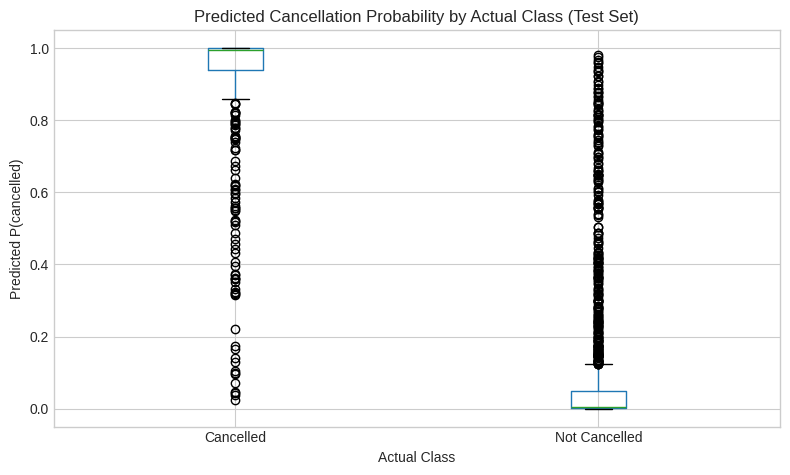

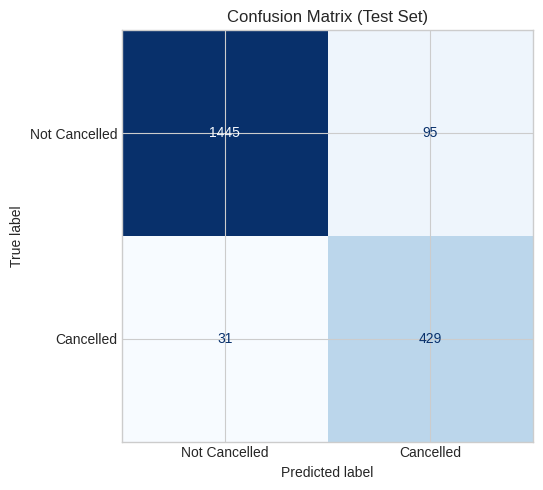

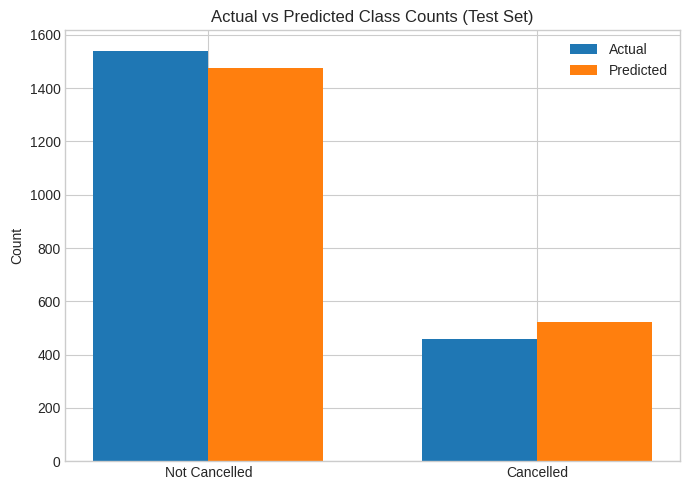

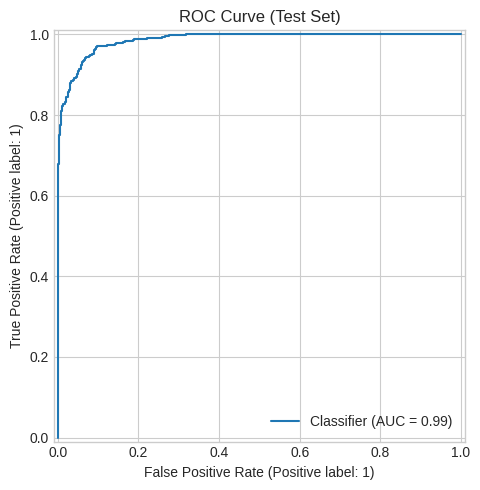

ROC-AUC (Test): 0.9862


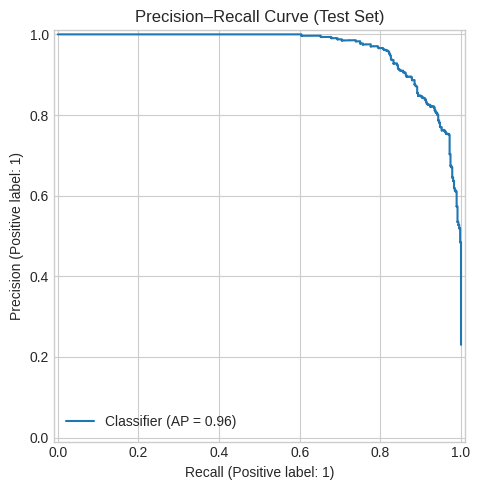

Average Precision (Test): 0.9633

Concise model interpretation:
- The model detects cancellations by ranking customers by P(cancelled); a higher ROC-AUC and Average Precision indicate better separation between cancelled and not-cancelled customers.
- Precision (TP / (TP + FP)) means: among customers predicted to cancel, what fraction truly cancel. High precision reduces the number of ‘false alarm’ interventions.
- Recall (TP / (TP + FN)) means: among truly cancelled customers, what fraction are caught by the model. Higher recall reduces missed cancellations.
- Based on the test confusion matrix: FP represent unnecessary outreach, while FN represent missed cancellations. If missing cancellations is more costly than extra outreach, you would generally prefer higher recall; if outreach cost is high, you would prefer higher precision.
- Limitations: results come from a single train/test split plus cross-validation summary; performance may vary with threshold choice and data changes. Also, 

In [35]:
# -------------------------
# 12. Boxplot: predicted cancellation probability by actual class
# -------------------------
# Use the test set for plotting
fig, ax = plt.subplots(figsize=(8, 5))
test_df_plot = pd.DataFrame({
    "actual_cancelled": y_test.values,
    "predicted_proba_cancelled": y_test_proba
})

# Map classes to labels
test_df_plot["actual_label"] = test_df_plot["actual_cancelled"].map({
    0: "Not Cancelled",
    1: "Cancelled"
})

# Boxplot
test_df_plot.boxplot(
    column="predicted_proba_cancelled",
    by="actual_label",
    ax=ax,
    grid=True
)
ax.set_title("Predicted Cancellation Probability by Actual Class (Test Set)")
ax.set_xlabel("Actual Class")
ax.set_ylabel("Predicted P(cancelled)")
plt.suptitle("")  # remove automatic pandas boxplot suptitle
plt.tight_layout()
plt.show()

# -------------------------
# 13. Confusion matrix plot
# -------------------------
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Cancelled", "Cancelled"]
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

# -------------------------
# 14. Actual vs predicted class-count bar chart
# -------------------------
actual_counts = pd.Series(y_test).value_counts().reindex([0, 1], fill_value=0)
pred_counts = pd.Series(y_test_pred).value_counts().reindex([0, 1], fill_value=0)

labels = ["Not Cancelled", "Cancelled"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, actual_counts.values, width=width, label="Actual")
ax.bar(x + width/2, pred_counts.values, width=width, label="Predicted")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Count")
ax.set_title("Actual vs Predicted Class Counts (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 15. ROC curve with ROC-AUC value
# -------------------------
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    ax=ax
)
ax.set_title("ROC Curve (Test Set)")
plt.tight_layout()
plt.show()

roc_auc_value = roc_auc_score(y_test, y_test_proba)
print(f"ROC-AUC (Test): {roc_auc_value:.4f}")

# -------------------------
# 16. Precision–Recall curve with Average Precision value
# -------------------------
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba,
    ax=ax
)
ax.set_title("Precision–Recall Curve (Test Set)")
plt.tight_layout()
plt.show()

avg_prec_value = average_precision_score(y_test, y_test_proba)
print(f"Average Precision (Test): {avg_prec_value:.4f}")

# -------------------------
# 17. Concise model interpretation
# -------------------------
print("\nConcise model interpretation:")
print(
    "- The model detects cancellations by ranking customers by P(cancelled); a higher ROC-AUC and Average Precision "
    "indicate better separation between cancelled and not-cancelled customers."
)
print(
    "- Precision (TP / (TP + FP)) means: among customers predicted to cancel, what fraction truly cancel. "
    "High precision reduces the number of ‘false alarm’ interventions."
)
print(
    "- Recall (TP / (TP + FN)) means: among truly cancelled customers, what fraction are caught by the model. "
    "Higher recall reduces missed cancellations."
)
print(
    "- Based on the test confusion matrix: FP represent unnecessary outreach, while FN represent missed cancellations. "
    "If missing cancellations is more costly than extra outreach, you would generally prefer higher recall; "
    "if outreach cost is high, you would prefer higher precision."
)
print(
    "- Limitations: results come from a single train/test split plus cross-validation summary; performance may vary "
    "with threshold choice and data changes. Also, Logistic Regression assumes a linear relationship in the learned "
    "feature space, which may not capture complex patterns fully."
)

#**Chapter 11. Ask Prompt to recommend suitable models for comparison**

In [41]:
df=cleaned2_df

prompt_suggest = f"""
You are an expert machine learning data scientist specialising in binary classification models.

The pandas DataFrame is named `df`.

=========================
TARGET
=========================
Target column:
customer_cancelled

Target values:
- 0 = Customer did not cancel
- 1 = Customer cancelled

=========================
DATASET PROFILE
=========================
{payload_text}

The dataset has already undergone preprocessing.

Assume the following preprocessing has been completed:
- Missing values have been handled.
- Identifier-like columns have been removed.
- Datetime columns have been removed or transformed into useful features.
- Known target leakage features have been removed.

Use ONLY the information contained in the Dataset Profile.

Do NOT assume:
- additional columns
- hidden relationships
- unknown distributions
- feature importance
- correlations
- missing values
- class imbalance beyond what is explicitly provided

If information cannot be determined from the Dataset Profile, explicitly state that it cannot be determined.

=========================
BUSINESS CONTEXT
=========================

Business Problem

Grab Ride Operations Manager has observed a high rate of customer cancellations before trip commencement.

Business Objective

Develop a machine learning model that predicts the probability that a customer will cancel a booking before trip commencement.

Business Goal

Reduce customer cancellations through proactive operational interventions while minimising unnecessary incentive costs.

Dataset Context

Each row represents one Grab booking.

Approximately 23% of bookings were cancelled before trip commencement.

The dataset contains customer information, booking details, driver availability, pricing, weather, traffic conditions and booking outcomes.

=========================
TASK
=========================

Provide recommendations based ONLY on the Dataset Profile and Business Context.

Justify every recommendation using BOTH:
- dataset characteristics
- business objective

Avoid generic machine learning advice.

Present answers using clear tables whenever appropriate.

====================================================
1. RECOMMEND SUITABLE MODELS
====================================================

Recommend ONLY the three strongest classification models for this problem.

For each model provide:

- Model name
- Why it is suitable
- Why it is appropriate for this dataset
- Advantages
- Limitations
- Whether it is suitable as a baseline model
- Whether it is suitable as a production model

====================================================
2. HYPERPARAMETERS
====================================================

For each recommended model list the most important hyperparameters.

For each hyperparameter provide:

- Parameter name
- Recommended starting value
- Recommended tuning range
- Why it is important
- Whether it mainly improves
    - generalisation
    - reduces overfitting
    - improves prediction performance
    - training efficiency

Recommend an appropriate hyperparameter tuning method.

Examples may include:
- RandomizedSearchCV
- GridSearchCV
- Bayesian Optimisation

Explain why your recommendation is appropriate.

====================================================
3. CROSS-VALIDATION
====================================================

Recommend an appropriate cross-validation strategy.

Explain:

- Recommended method
- Number of folds
- Whether stratification should be used
- Why it is suitable
- How it improves model reliability
- How it reduces overfitting risk

====================================================
4. EVALUATION METRICS
====================================================

Recommend suitable evaluation metrics for this business problem.

For each metric explain:

- What it measures
- Why it is appropriate
- Whether higher or lower is better
- Strengths
- Weaknesses
- When it should be prioritised

Separate metrics into:

Model discrimination
Examples:
- ROC-AUC
- PR-AUC

Classification metrics
Examples:
- Precision
- Recall
- F1-score
- MCC
- Confusion Matrix

Probability metrics
Examples:
- Log Loss
- Brier Score

Business metrics

Explain how each metric relates to reducing customer cancellations while avoiding excessive intervention costs.

====================================================
5. THRESHOLD OPTIMISATION
====================================================

Recommend how the classification probability threshold should be selected.

Discuss:

- Why 0.50 may not be optimal
- Precision vs Recall trade-off
- False Positive vs False Negative trade-offs
- Business implications
- Recommended approach for this problem

====================================================
6. PROBABILITY CALIBRATION
====================================================

Because the objective is to predict cancellation probability rather than only the class label, recommend whether probability calibration should be performed.

Discuss:

- Calibration Curve
- Brier Score
- Platt Scaling
- Isotonic Regression

Explain why calibration is important for operational decision-making.

====================================================
7. EXPLORATORY DATA ANALYSIS (EDA)
====================================================

Recommend useful EDA before modelling.

For each plot explain:

- What it shows
- Why it is useful
- What modelling insight it may provide

Include suitable plots for:

- Target distribution
- Numerical features
- Categorical features
- Correlation analysis
- Missing values (if applicable)
- Class imbalance
- Feature distributions
- Outlier detection

====================================================
8. MODEL EVALUATION PLOTS
====================================================

Recommend useful plots after training.

For each plot explain:

- What it shows
- How it evaluates classifier performance
- Why it is useful for the business problem

Examples include:

- ROC Curve
- Precision-Recall Curve
- Confusion Matrix
- Calibration Curve
- Lift Chart
- Gain Chart
- Probability Distribution
- Feature Importance
- SHAP Summary Plot
- Partial Dependence Plot
- Permutation Importance

====================================================
9. MODEL INTERPRETABILITY
====================================================

Recommend appropriate explainability techniques.

Discuss:

- Feature Importance
- Permutation Importance
- SHAP
- Logistic Regression coefficients (if applicable)

Explain:

- when each method should be used
- strengths
- limitations
- suitability for communicating results to business stakeholders

====================================================
10. RECOMMENDED MODELLING WORKFLOW
====================================================

Recommend an end-to-end modelling workflow.

Include:

1. Data preprocessing
2. Baseline model
3. Candidate models
4. Cross-validation
5. Hyperparameter tuning
6. Probability calibration
7. Threshold optimisation
8. Final model selection
9. Business evaluation
10. Deployment recommendation

Conclude by recommending the single best modelling strategy for this project and justify your recommendation using only the Dataset Profile and Business Context.
"""



##print('=== Prompt to send ===')
##print(prompt_testing)

response_suggest = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_suggest
)
print('\n=== LLM response ===')
print(response_suggest.output_text)



=== LLM response ===
Below are recommendations tailored to **predict pre-trip cancellation probability** (target `customer_cancelled`, ~**23%** positive) using only what can be inferred from the Dataset Profile.

---

## 1) Suitable models (top 3)

| Model name | Why it is suitable | Why it is appropriate for this dataset | Advantages | Limitations | Baseline? | Production? |
|---|---|---|---|---|---|---|
| **LightGBM (Gradient Boosted Trees)** | Handles mixed feature types and non-linear relationships well; strong for tabular binary classification | Many categorical features (`day_of_week`, zones, vehicle/payment/segment/loyalty, weather, traffic_level, app_version, network_quality). Strong signal likely from non-linear interactions (e.g., driver/availability vs demand vs weather). No missing values; no leakage columns detected | High predictive power on tabular data; efficient training; handles high-cardinality categoricals via encoding options; supports probability outputs | Requir

#**Section 2: Define Target and Remove Leakage Columns**

In [ ]:
target = "customer_cancelled"

X = df.drop(columns=[target])
y = df[target]

print(X.shape)
print(y.value_counts(normalize=True))

(10000, 42)
customer_cancelled
0    0.77
1    0.23
Name: proportion, dtype: float64


#**Section 3: Correlation for Numeric Variables**

In [ ]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

corr_df = df[numeric_cols.tolist() + [target]].corr()[target] \
    .drop(target) \
    .sort_values(key=abs, ascending=False) \
    .reset_index()

corr_df.columns = ["Feature", "Correlation with customer_cancelled"]

corr_df.head(50)

,Feature,Correlation with customer_cancelled
0,surge_multiplier,0.697512
1,driver_eta_min,0.641218
2,is_peak_hour,0.567279
3,supply_demand_ratio,-0.542120
4,drivers_declined_before_accept,0.523173
5,driver_distance_to_pickup_km,0.480110
6,booking_demand_zone,0.469453
7,active_driver_supply_zone,-0.441864
8,driver_acceptance_time_sec,0.369772
9,estimated_fare_sgd,0.336150


#**Correlations for Categorical features**

In [ ]:
#Option 1: Cramér's V

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()

    phi2 = chi2 / n
    r, k = confusion.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

target = "customer_cancelled"

cat_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

cramers_results = []

for col in cat_cols:
    score = cramers_v(df[col], df[target])

    cramers_results.append({
        "Feature": col,
        "Cramers_V": score
    })

cramers_df = (
    pd.DataFrame(cramers_results)
      .sort_values("Cramers_V", ascending=False)
)

display(cramers_df)

,Feature,Cramers_V
10,traffic_level,0.423727
9,weather,0.241832
2,pickup_zone_type,0.102395
1,pickup_zone,0.101002
7,customer_segment,0.090539
8,loyalty_tier,0.041938
3,dropoff_zone,0.030594
4,dropoff_zone_type,0.025254
5,vehicle_type,0.023367
0,day_of_week,0.001085


In [ ]:
# Option2:One-Hot Encode + Correlation (Simple)

target = "customer_cancelled"

cat_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

encoded = pd.get_dummies(
    df[cat_cols],
    drop_first=False
)

corr_df = (
    encoded.join(df[target])
           .corr()[target]
           .drop(target)
           .sort_values(key=abs, ascending=False)
           .reset_index()
)

corr_df.columns = [
    "Feature",
    "Correlation with customer_cancelled"
]

display(corr_df.head(40))


,Feature,Correlation with customer_cancelled
0,traffic_level_Severe,0.358527
1,weather_Light Rain,0.206191
2,traffic_level_Low,-0.199922
3,traffic_level_Medium,-0.163701
4,traffic_level_High,0.147799
5,weather_Clear,-0.126735
6,weather_Heavy Rain,0.108666
7,pickup_zone_type_Airport,0.086956
8,pickup_zone_Changi,0.086956
9,customer_segment_New,0.080224


#**Section 4. Prepare data for machine learning**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

#**Section 5. Logistic Regression coefficients**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['booking_hour', 'is_weekend',
                                                   'is_peak_hour',
                                                   'is_late_night',
                                                   'public_holiday',
                                                   'airport_trip', 'cbd_trip',
                                                   'distance_km',
                                                   'estimated_trip_duration_min',
                                                   'customer_tenure_days',
                                                   'rides_last_7_days',...
                                                   'estimated_fare_sgd']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pickup_zone',
                                                   'pickup_zone_type',
                                                   'dropoff_zone',
                                                   'dropoff_zone_type',
                                                   'vehicle_type',
                                                   'customer_segment',
                                                   'loyalty_tier', 'weather',
                                                   'traffic_level'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
import numpy as np

feature_names = log_model.named_steps["preprocess"].get_feature_names_out()
coefficients = log_model.named_steps["model"].coef_[0]

log_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values("Abs_Coefficient", ascending=False)

log_coef_df.head(60)

,Feature,Coefficient,Abs_Coefficient
23,num__driver_eta_min,2.606577,2.606577
95,cat__traffic_level_Severe,1.635297,1.635297
24,num__surge_multiplier,1.626065,1.626065
81,cat__customer_segment_New,1.483262,1.483262
80,cat__customer_segment_High Value,-1.292730,1.292730
20,num__drivers_declined_before_accept,1.215007,1.215007
88,cat__weather_Clear,-0.977738,0.977738
89,cat__weather_Cloudy,-0.900515,0.900515
94,cat__traffic_level_Medium,-0.823730,0.823730
83,cat__customer_segment_Regular,-0.773012,0.773012


#**Section 6. Random Forest feature importance**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['booking_hour', 'is_weekend',
                                                   'is_peak_hour',
                                                   'is_late_night',
                                                   'public_holiday',
                                                   'airport_trip', 'cbd_trip',
                                                   'distance_km',
                                                   'estimated_trip_duration_min',
                                                   'customer_tenure_days',
                                                   'rides_last_7_days',...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pickup_zone',
                                                   'pickup_zone_type',
                                                   'dropoff_zone',
                                                   'dropoff_zone_type',
                                                   'vehicle_type',
                                                   'customer_segment',
                                                   'loyalty_tier', 'weather',
                                                   'traffic_level'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['booking_hour', 'is_weekend',
                                                   'is_peak_hour',
                                                   'is_late_night',
                                                   'public_holiday',
                                                   'airport_trip', 'cbd_trip',
                                                   'distance_km',
                                                   'estimated_trip_duration_min',
                                                   'customer_tenure_days',
                                                   'rides_last_7_days',...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pickup_zone',
                                                   'pickup_zone_type',
                                                   'dropoff_zone',
                                                   'dropoff_zone_type',
                                                   'vehicle_type',
                                                   'customer_segment',
                                                   'loyalty_tier', 'weather',
                                                   'traffic_level'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

print("XGBoost model trained.")

XGBoost model trained.


#**Section 7. SHAP values**

In [ ]:
!pip install shap -q

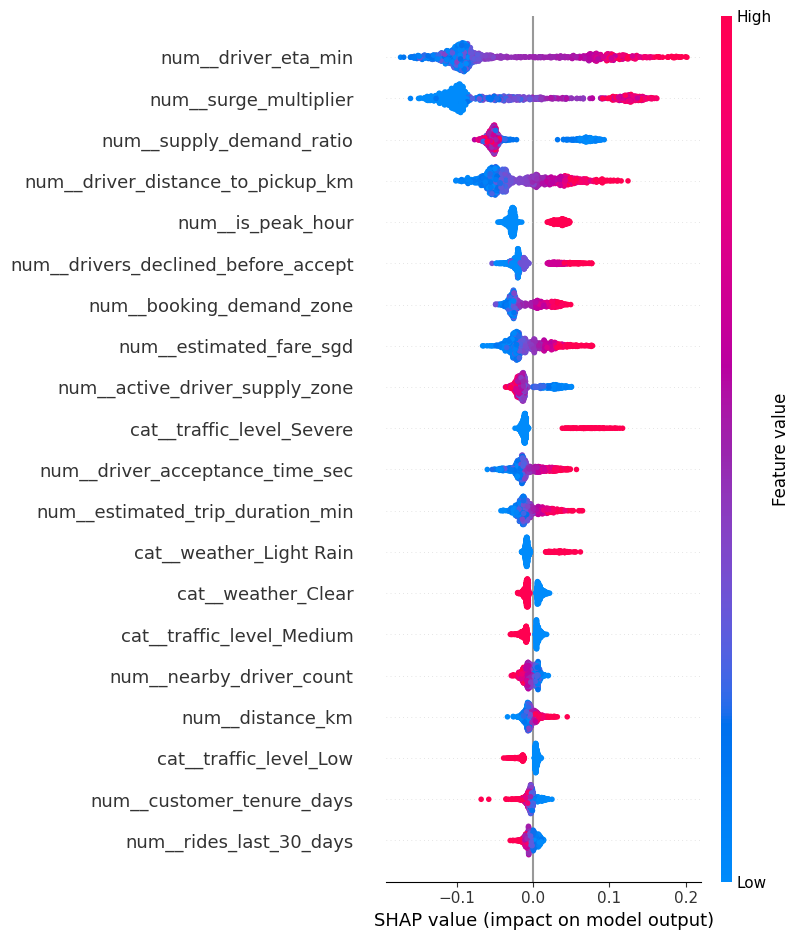

In [ ]:
import shap

# Transform training and test data
X_train_transformed = rf_model.named_steps["preprocess"].transform(X_train)
X_test_transformed = rf_model.named_steps["preprocess"].transform(X_test)

# Convert sparse matrix to dense if needed
X_test_dense = X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed
import shap

# Transform test data
X_test_transformed = rf_model.named_steps["preprocess"].transform(X_test)

# Convert sparse matrix to dense if needed
X_test_dense = (
    X_test_transformed.toarray()
    if hasattr(X_test_transformed, "toarray")
    else X_test_transformed
)

# Get transformed feature names
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Use a sample
sample_size = 1000
X_shap = X_test_dense[:sample_size]

# Convert X_shap back to DataFrame with feature names
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

# SHAP
explainer = shap.TreeExplainer(rf_model.named_steps["model"])
shap_values = explainer.shap_values(X_shap)

# For binary classification: class 1 = customer cancelled
shap_cancelled = shap_values[:, :, 1]

shap.summary_plot(
    shap_cancelled,
    X_shap_df
)
# Use a sample to keep SHAP fast
sample_size = 1000
X_shap = X_test_dense[:sample_size]

explainer = shap.TreeExplainer(rf_model.named_steps["model"])
shap_values = explainer.shap_values(X_shap)

In [ ]:
#Checking the shape of shap values
print("X_shap shape:", X_shap.shape)
print("Type of shap_values:", type(shap_values))

if isinstance(shap_values, list):
    print("shap_values[0] shape:", shap_values[0].shape)
    print("shap_values[1] shape:", shap_values[1].shape)
else:
    print("shap_values shape:", shap_values.shape)
print(type(X_shap))
print(type(X_shap_df))
print(X_shap.shape)
print(X_shap_df.shape)

X_shap shape: (1000, 96)
Type of shap_values: <class 'numpy.ndarray'>
shap_values shape: (1000, 96, 2)
<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
(1000, 96)
(1000, 96)


In [ ]:
print("rf_importance_df" in globals())

False


#**Section 8. Create final comparison table**

In [ ]:
import pandas as pd

# Get transformed feature names after preprocessing
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Get Random Forest feature importances
rf_importances = rf_model.named_steps["model"].feature_importances_

# Create DataFrame
rf_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "RF_Importance": rf_importances
    })
    .sort_values("RF_Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_importance_df.head(15))

,Feature,RF_Importance
0,num__surge_multiplier,0.181055
1,num__driver_eta_min,0.155915
2,num__supply_demand_ratio,0.105829
3,num__driver_distance_to_pickup_km,0.072124
4,num__is_peak_hour,0.058860
5,num__active_driver_supply_zone,0.050850
6,num__booking_demand_zone,0.042234
7,num__drivers_declined_before_accept,0.033944
8,num__estimated_fare_sgd,0.029123
9,num__driver_acceptance_time_sec,0.027687


In [ ]:
top_corr = corr_df.head(15)
top_log = log_coef_df.head(15)
top_rf = rf_importance_df.head(15)

print("Top Numeric Correlations")
display(top_corr)

print("Top Logistic Regression Coefficients")
display(top_log)

print("Top Random Forest Importances")
display(top_rf)

Top Numeric Correlations


,Feature,Correlation with customer_cancelled
0,surge_multiplier,0.697512
1,driver_eta_min,0.641218
2,is_peak_hour,0.567279
3,supply_demand_ratio,-0.542120
4,drivers_declined_before_accept,0.523173
5,driver_distance_to_pickup_km,0.480110
6,booking_demand_zone,0.469453
7,active_driver_supply_zone,-0.441864
8,driver_acceptance_time_sec,0.369772
9,estimated_fare_sgd,0.336150


Top Logistic Regression Coefficients


,Feature,Coefficient,Abs_Coefficient
23,num__driver_eta_min,2.606577,2.606577
95,cat__traffic_level_Severe,1.635297,1.635297
24,num__surge_multiplier,1.626065,1.626065
81,cat__customer_segment_New,1.483262,1.483262
80,cat__customer_segment_High Value,-1.292730,1.292730
20,num__drivers_declined_before_accept,1.215007,1.215007
88,cat__weather_Clear,-0.977738,0.977738
89,cat__weather_Cloudy,-0.900515,0.900515
94,cat__traffic_level_Medium,-0.823730,0.823730
83,cat__customer_segment_Regular,-0.773012,0.773012


Top Random Forest Importances


,Feature,RF_Importance
0,num__surge_multiplier,0.181055
1,num__driver_eta_min,0.155915
2,num__supply_demand_ratio,0.105829
3,num__driver_distance_to_pickup_km,0.072124
4,num__is_peak_hour,0.058860
5,num__active_driver_supply_zone,0.050850
6,num__booking_demand_zone,0.042234
7,num__drivers_declined_before_accept,0.033944
8,num__estimated_fare_sgd,0.029123
9,num__driver_acceptance_time_sec,0.027687


## **Section 9. Evaluate Model Performance**

In [ ]:
from sklearn.metrics import classification_report

# Evaluate Logistic Regression Model
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96      1540
           1       0.81      0.93      0.87       460

    accuracy                           0.93      2000
   macro avg       0.89      0.93      0.91      2000
weighted avg       0.94      0.93      0.94      2000



In [ ]:
# Evaluate Random Forest Model
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1540
           1       0.85      0.85      0.85       460

    accuracy                           0.93      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.93      0.93      0.93      2000



In [ ]:
# Evaluate XGBoost Model
y_pred_rf = xgb_model.predict(X_test)
print("XGBoost Report:")
print(classification_report(y_test, y_pred_rf))

XGBoost Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1540
           1       0.89      0.85      0.87       460

    accuracy                           0.94      2000
   macro avg       0.93      0.91      0.92      2000
weighted avg       0.94      0.94      0.94      2000



Recommended RandomizedSearchCV

Randomised search is usually more practical than Grid Search because XGBoost has many parameters and combinations.


In [ ]:

import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedShuffleSplit
)

# ---------------------------------------------------------
# 1. Calculate class imbalance from the training data
# ---------------------------------------------------------
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative records:", negative_count)
print("Positive records:", positive_count)
print("Suggested scale_pos_weight:", round(scale_pos_weight, 3))


# ---------------------------------------------------------
# 2. Create the XGBoost pipeline
# ---------------------------------------------------------
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),

    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])


# ---------------------------------------------------------
# 3. Define parameter distributions
#
# Pipeline parameters must begin with "model__"
# ---------------------------------------------------------
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500, 700, 1000],

    "model__learning_rate": [
        0.01, 0.03, 0.05, 0.08, 0.1, 0.2
    ],

    "model__max_depth": [2, 3, 4, 5, 6, 8, 10],

    "model__min_child_weight": [1, 2, 3, 5, 7, 10],

    "model__gamma": [0, 0.05, 0.1, 0.2, 0.5, 1],

    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],

    "model__colsample_bytree": [
        0.6, 0.7, 0.8, 0.9, 1.0
    ],

    "model__reg_alpha": [0, 0.001, 0.01, 0.1, 0.5, 1],

    "model__reg_lambda": [0.5, 1, 2, 5, 10],

    # Compare no extra positive-class weighting with several weights
    "model__scale_pos_weight": [
        1,
        scale_pos_weight * 0.5,
        scale_pos_weight,
        scale_pos_weight * 1.5
    ]
}


# ---------------------------------------------------------
# 4. Stratified cross-validation
# ---------------------------------------------------------
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=42
)


# ---------------------------------------------------------
# 5. Run RandomizedSearchCV
#
# scoring="average_precision" is suitable when the positive
# cancellation class is less common.
# ---------------------------------------------------------
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

xgb_search.fit(X_train, y_train)


# ---------------------------------------------------------
# 6. Retrieve the best model
# ---------------------------------------------------------
best_xgb_model = xgb_search.best_estimator_

print("\nBest cross-validation Average Precision:")
print(round(xgb_search.best_score_, 4))

print("\nBest parameters:")
for parameter, value in xgb_search.best_params_.items():
    print(f"{parameter}: {value}")

Negative records: 6160
Positive records: 1840
Suggested scale_pos_weight: 3.348
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best cross-validation Average Precision:
0.9514

Best parameters:
model__subsample: 0.9
model__scale_pos_weight: 1.673913043478261
model__reg_lambda: 10
model__reg_alpha: 0.001
model__n_estimators: 500
model__min_child_weight: 3
model__max_depth: 2
model__learning_rate: 0.1
model__gamma: 0.1
model__colsample_bytree: 0.6


Evaluate the tuned model on the untouched test set

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Class predictions
y_test_pred = best_xgb_model.predict(X_test)

# Probability that customer_cancelled = 1
y_test_proba = best_xgb_model.predict_proba(X_test)[:, 1]

tuned_xgb_results = pd.DataFrame([{
    "model": "Tuned XGBoost",
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision": precision_score(
        y_test, y_test_pred, zero_division=0
    ),
    "recall": recall_score(
        y_test, y_test_pred, zero_division=0
    ),
    "f1_score": f1_score(
        y_test, y_test_pred, zero_division=0
    ),
    "roc_auc": roc_auc_score(y_test, y_test_proba),
    "average_precision": average_precision_score(
        y_test, y_test_proba
    )
}])

display(tuned_xgb_results.round(4))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Not Cancelled", "Cancelled"],
        zero_division=0
    )
)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Tuned XGBoost,0.9465,0.8732,0.8978,0.8853,0.9856,0.9627



Classification report:
               precision    recall  f1-score   support

Not Cancelled       0.97      0.96      0.97      1540
    Cancelled       0.87      0.90      0.89       460

     accuracy                           0.95      2000
    macro avg       0.92      0.93      0.93      2000
 weighted avg       0.95      0.95      0.95      2000


Confusion matrix:
[[1480   60]
 [  47  413]]


- Inspect whether the tuned model is overfitting
- A noticeably higher training score than validation score may suggest overfitting.

In [ ]:
cv_results = pd.DataFrame(xgb_search.cv_results_)

best_index = xgb_search.best_index_

best_train_ap = cv_results.loc[
    best_index, "mean_train_score"
]

best_validation_ap = cv_results.loc[
    best_index, "mean_test_score"
]

train_validation_gap = best_train_ap - best_validation_ap

print("CV train Average Precision:",
      round(best_train_ap, 4))

print("CV validation Average Precision:",
      round(best_validation_ap, 4))

print("Train-validation gap:",
      round(train_validation_gap, 4))

CV train Average Precision: 0.9812
CV validation Average Precision: 0.9514
Train-validation gap: 0.0298
